# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
from cmath import nan

import pandas as pd
population = pd.read_csv("data/population.csv", skiprows=4)
gdp = pd.read_csv("data/GDP.csv",)
life_expectancy = pd.read_csv("data/LE.csv", skiprows=4)
literacy_rate = pd.read_csv("data/LR.csv", skiprows=4)

print(gdp.columns)

population_small = population[['Country Name', 'Country Code', '2024']]
gdp_small = gdp[['Country Name', '2024 [YR2024]']]
life_expectancy_small = life_expectancy[['Country Name', '2024']]


population_small = population_small.rename(columns={'2024': 'population'})
gdp_small = gdp_small.rename(columns={'2024': 'GDP_per_Capita'})
life_expectancy_small = life_expectancy_small.rename({'2024': 'Life_Expectancy'})

df = population_small
df = pd.merge(df, life_expectancy_small, on='Country Name')
df = pd.merge(df, gdp_small, on='Country Name')

print(df.head())



Index(['Series Name', 'Series Code', 'Country Name', 'Country Code',
       '1990 [YR1990]', '2000 [YR2000]', '2016 [YR2016]', '2017 [YR2017]',
       '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]',
       '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]'],
      dtype='object')
                  Country Name Country Code   population       2024  \
0                        Aruba          ABW     107995.0  76.500000   
1  Africa Eastern and Southern          AFE  769280888.0  65.349930   
2                  Afghanistan          AFG   42647492.0  66.289000   
3   Africa Western and Central          AFW  520655398.0  59.041538   
4                       Angola          AGO   37885849.0  64.805000   

        2024 [YR2024]  
0    6.18175077559285  
1   0.277358647887979  
2  -0.975915304703463  
3    2.11770319005143  
4    1.80585033622316  


In [4]:
df.isna().sum
df = df.fillna(0)
df = df.rename(columns={'2024 [YR2024]': 'GDP_per_Capita'})
df["GDP_per_Capita"] = pd.to_numeric(df["GDP_per_Capita"], errors='coerce')

print(df["GDP_per_Capita"].mean())
print(df["GDP_per_Capita"].median)
print(df["GDP_per_Capita"].std())
print(df["GDP_per_Capita"].min())
print(df["GDP_per_Capita"].max())

mean_GDP = df["GDP_per_Capita"].mean()
median_GDP = df["GDP_per_Capita"].median()
std_GDP = df["GDP_per_Capita"].std()
min_GDP = df["GDP_per_Capita"].min()
max_GDP = df["GDP_per_Capita"].max()
print(mean_GDP)
print(median_GDP)
print(std_GDP)

top_10 = df.sort_values(by='GDP_per_Capita', ascending=False).head(10)
bottom_10 = df.sort_values(by='GDP_per_Capita', ascending=True).head(10)
print(top_10)
print(bottom_10)

highest = df.loc[df['GDP_per_Capita'].idxmax()]
print(highest)

lowest = df.loc[df['GDP_per_Capita'].idxmin()]
print(lowest)

print(df[['population', 'GDP_per_Capita', '2024']].describe())


2.0913387903809872
<bound method Series.median of 0       6.181751
1       0.277359
2      -0.975915
3       2.117703
4       1.805850
         ...    
260    10.365649
261          NaN
262    -0.713538
263     0.941473
264    -0.117816
Name: GDP_per_Capita, Length: 265, dtype: float64>
4.379472687761575
-24.6567900497018
43.0000558343687
2.0913387903809872
2.12892891697799
4.379472687761575
               Country Name Country Code  population       2024  \
93                   Guyana          GUY    831087.0  70.319000   
49   Caribbean small states          CSS   4539060.0  73.312667   
187                   Palau          PLW     17695.0  69.383000   
260                  Kosovo          XKX   1594353.0  78.222000   
121         Kyrgyz Republic          KGZ   7221868.0  72.400000   
148                  Monaco          MCO     38631.0  86.497000   
81                  Georgia          GEO   3812518.0  74.657000   
154        Marshall Islands          MHL     37548.0  67.075000   
32

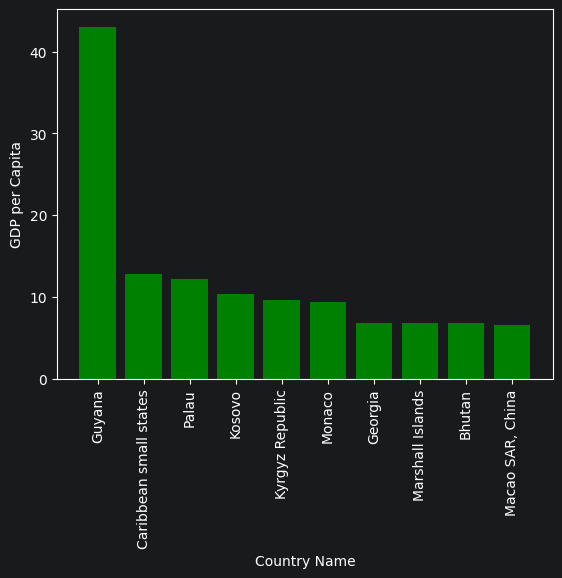

In [5]:
import matplotlib.pyplot as plt

plt.bar(top_10['Country Name'], top_10['GDP_per_Capita'], color='green')
plt.xticks(rotation=90)
plt.ylabel('GDP per Capita')
plt.xlabel('Country Name')
plt.show()


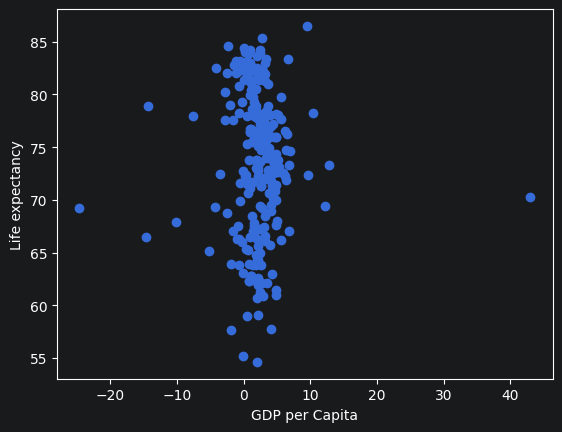

In [6]:
plt.scatter(df["GDP_per_Capita"], df["2024"])
plt.xlabel("GDP per Capita")
plt.ylabel("Life expectancy")
plt.show()


In [8]:
import plotly.express as px

fig = px.choropleth(df, locations='Country Code', color='GDP_per_Capita', hover_name='Country Name', title='GDP per Capita per country', color_continuous_scale='viridis')
fig.show()
